In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import xclimate as xclim

In [75]:
from matplotlib.colors import LinearSegmentedColormap

brbg = plt.get_cmap("PRGn", 256)
colors = brbg(np.linspace(0, 1, 256))

center = 128
half_width = 12
lo, hi = center - half_width, center + half_width + 1

white = np.array([1.0, 1.0, 1.0, 1.0])

# left side: color -> white
t_left = np.linspace(0, 1, center - lo + 1)
colors[lo:center+1] = colors[lo:center+1] * (1 - t_left[:, None]) + white * t_left[:, None]

# right side: white -> color
t_right = np.linspace(1, 0, hi - center)
colors[center:hi] = colors[center:hi] * (1 - t_right[:, None]) + white * t_right[:, None]

cmap = LinearSegmentedColormap.from_list("PRGn_white_center_smooth", colors)

# FHIST

In [3]:
## FHIST PPE

variables = [
    "TLAI_month_1",
]

grid = xclim.load_fhist_ppe_grid()

fhist = {}
for v in variables:
    print(f"  {v}")
    name = "_".join(v.split("_")[:-2])
    fhist[v] = xclim.load_fhist(v, keep_var_only=True)[name].reindex_like(grid, method="nearest", tolerance=1e-3)
    fhist[v] = fhist[v].chunk({'time': -1, 'lat': -1, 'lon': -1}).compute()

  TLAI_month_1


In [61]:
lai_gm_ts = fhist['TLAI_month_1'].weighted(grid.LANDAREA).mean(dim=['lat', 'lon'])

lai_gm_sc = lai_gm_ts.groupby('time.month').mean()
lai_gm_dsc = lai_gm_ts.groupby('time.month') - lai_gm_sc

lai_gm_ta = lai_gm_ts.groupby('time.year').map(lambda x: x.weighted(x.time.dt.days_in_month).mean(dim='time')).mean(dim='year')
lai_gm_yr = lai_gm_ts.groupby('time.year').map(lambda x: x.weighted(x.time.dt.days_in_month).mean(dim='time')) - lai_gm_ta

lai_gm_dsc['time'] = lai_gm_dsc.time.dt.year + (lai_gm_dsc.time.dt.dayofyear - 1) / 365.25

In [62]:
lai_gm_dsc_ols = xclim.regression.ols_field(lai_gm_dsc.time, lai_gm_dsc, sample_dim='time', alpha=0.05)
lai_gm_yr_ols = xclim.regression.ols_field(lai_gm_yr.year, lai_gm_yr, sample_dim='year', alpha=0.05)

In [63]:
lai_gm_dsc_1990_ols = xclim.regression.ols_field(lai_gm_dsc.time.sel(time=slice('1990-01', None)), lai_gm_dsc.sel(time=slice('1990-01', None)), sample_dim='time', alpha=0.05)
lai_gm_yr_1990_ols = xclim.regression.ols_field(lai_gm_yr.year.sel(year=slice(1990, None)), lai_gm_yr.sel(year=slice(1990, None)), sample_dim='year', alpha=0.05)

In [64]:
lai_ts = fhist['TLAI_month_1']

lai_sc = lai_ts.groupby('time.month').mean()
lai_dsc = lai_ts.groupby('time.month') - lai_sc

lai_ta = lai_ts.groupby('time.year').map(lambda x: x.weighted(x.time.dt.days_in_month).mean(dim='time')).mean(dim='year')
lai_yr = lai_ts.groupby('time.year').map(lambda x: x.weighted(x.time.dt.days_in_month).mean(dim='time')) - lai_ta

lai_dsc['time'] = lai_dsc.time.dt.year + (lai_dsc.time.dt.dayofyear - 1) / 365.25

In [65]:
lai_dsc_ols = xclim.regression.ols_field(lai_dsc.time, lai_dsc, sample_dim='time', alpha=0.05)
lai_yr_ols = xclim.regression.ols_field(lai_yr.year, lai_yr, sample_dim='year', alpha=0.05)

In [66]:
lai_dsc_1990_ols = xclim.regression.ols_field(lai_dsc.time.sel(time=slice('1990-01', None)), lai_dsc.sel(time=slice('1990-01', None)), sample_dim='time', alpha=0.05)
lai_yr_1990_ols = xclim.regression.ols_field(lai_yr.year.sel(year=slice(1990, None)), lai_yr.sel(year=slice(1990, None)), sample_dim='year', alpha=0.05)

In [67]:
lai_gc_mn = fhist['TLAI_month_1'].groupby('time.year').map(lambda x: x.weighted(x.time.dt.days_in_month).mean(dim='time')).mean(dim='year')
lai_dsc_pct_per_yr_masked = (lai_dsc_ols.slope_fdr_masked / lai_gc_mn) * 100
lai_dsc_pct_per_yr = (lai_dsc_ols.slope / lai_gc_mn) * 100

lai_gc_mn = fhist['TLAI_month_1'].sel(time=slice('1990-01', None)).groupby('time.year').map(lambda x: x.weighted(x.time.dt.days_in_month).mean(dim='time')).mean(dim='year')
lai_dsc_1990_pct_per_yr_masked = (lai_dsc_1990_ols.slope_fdr_masked / lai_gc_mn) * 100
lai_dsc_1990_pct_per_yr = (lai_dsc_1990_ols.slope / lai_gc_mn) * 100

# LENS2

In [8]:
## CESM2 LE

variables_lens = [
    "TLAI",
]

grid_lens = xclim.load_cesm2le_grid()

lens = {}
for v in variables_lens:
    print(f"  {v}")
    vv = f"{v}_month_1"
    lens[vv] = xclim.load_cesm2le(v, "lnd", "month_1", "h0", keep_var_only=True).sel(time=slice('1950-01', '2014-12'))[v].reindex_like(grid_lens, method="nearest", tolerance=1e-3)
    lens[vv] = lens[vv].chunk({'time': -1, 'lat': -1, 'lon': -1}).compute()

  TLAI


In [68]:
lens_lai_gm_ts = lens['TLAI_month_1'].weighted(grid_lens.LANDAREA).mean(dim=['lat', 'lon'])

lens_lai_gm_sc = lens_lai_gm_ts.groupby('time.month').mean()
lens_lai_gm_dsc = lens_lai_gm_ts.groupby('time.month') - lens_lai_gm_sc

lens_lai_gm_ta = lens_lai_gm_ts.groupby('time.year').map(lambda x: x.weighted(x.time.dt.days_in_month).mean(dim='time')).mean(dim='year')
lens_lai_gm_yr = lens_lai_gm_ts.groupby('time.year').map(lambda x: x.weighted(x.time.dt.days_in_month).mean(dim='time')) - lens_lai_gm_ta

lens_lai_gm_dsc['time'] = lens_lai_gm_dsc.time.dt.year + (lens_lai_gm_dsc.time.dt.dayofyear - 1) / 365.25

In [69]:
lens_lai_gm_dsc_ols = xclim.regression.ols_field(lens_lai_gm_dsc.time, lens_lai_gm_dsc, sample_dim='time', alpha=0.05)
lens_lai_gm_yr_ols = xclim.regression.ols_field(lens_lai_gm_yr.year, lens_lai_gm_yr, sample_dim='year', alpha=0.05)

In [70]:
lens_lai_gm_dsc_1990_ols = xclim.regression.ols_field(lens_lai_gm_dsc.time.sel(time=slice('1990-01', None)), lens_lai_gm_dsc.sel(time=slice('1990-01', None)), sample_dim='time', alpha=0.05)
lens_lai_gm_yr_1990_ols = xclim.regression.ols_field(lens_lai_gm_yr.year.sel(year=slice(1990, None)), lens_lai_gm_yr.sel(year=slice(1990, None)), sample_dim='year', alpha=0.05)

# plots

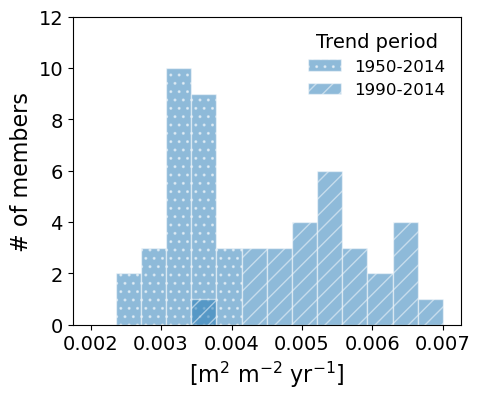

In [71]:
fig, ax = plt.subplots(figsize=(5, 4))
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
lai_gm_dsc_ols.slope.where(lai_gm_dsc_ols.slope_p_value < 0.01).plot.hist(ax=ax, bins=np.linspace(0.002, 0.007, 15), color='tab:blue', hatch='..', edgecolor='white', alpha=0.5, label='1950-2014')
lai_gm_dsc_1990_ols.slope.where(lai_gm_dsc_1990_ols.slope_p_value < 0.01).plot.hist(ax=ax, bins=np.linspace(0.002, 0.007, 15), color='tab:blue', hatch='//', edgecolor='white', alpha=0.5, label='1990-2014')
ax.set_yticks([0, 2, 4, 6, 8, 10, 12])
ax.set_xlabel('[m$^{2}$ m$^{-2}$ yr$^{-1}$]')
ax.set_ylabel('# of members')
ax.legend(fontsize=12, title='Trend period', title_fontproperties={'size': 14}, frameon=False, loc='upper right')
# xclim.plot.center_axis_at_zero(ax, 'x')

fig.savefig('fig/lmwg/trend.dsc.hist.lnd.LAI.FHIST.png', dpi=300, bbox_inches='tight')

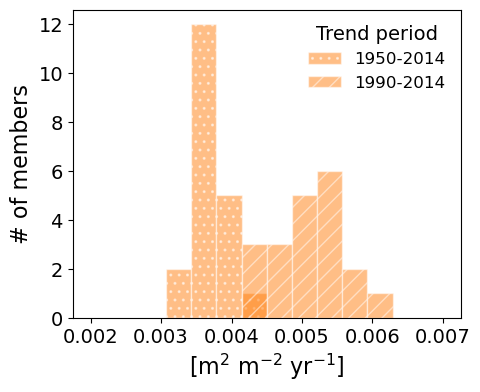

In [72]:
fig, ax = plt.subplots(figsize=(5, 4))
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
lens_lai_gm_dsc_ols.slope.where(lens_lai_gm_dsc_ols.slope_p_value < 0.01).plot.hist(ax=ax, bins=np.linspace(0.002, 0.007, 15), color='tab:orange', hatch='..', edgecolor='white', alpha=0.5, label='1950-2014')
lens_lai_gm_dsc_1990_ols.slope.where(lens_lai_gm_dsc_1990_ols.slope_p_value < 0.01).plot.hist(ax=ax, bins=np.linspace(0.002, 0.007, 15), color='tab:orange', hatch='//', edgecolor='white', alpha=0.5, label='1990-2014')
ax.set_yticks([0, 2, 4, 6, 8, 10, 12])
ax.set_xlabel('[m$^{2}$ m$^{-2}$ yr$^{-1}$]')
ax.set_ylabel('# of members')
ax.legend(fontsize=12, title='Trend period', title_fontproperties={'size': 14}, frameon=False, loc='upper right')

fig.savefig('fig/lmwg/trend.dsc.hist.lnd.LAI.LENS2.png', dpi=300, bbox_inches='tight')

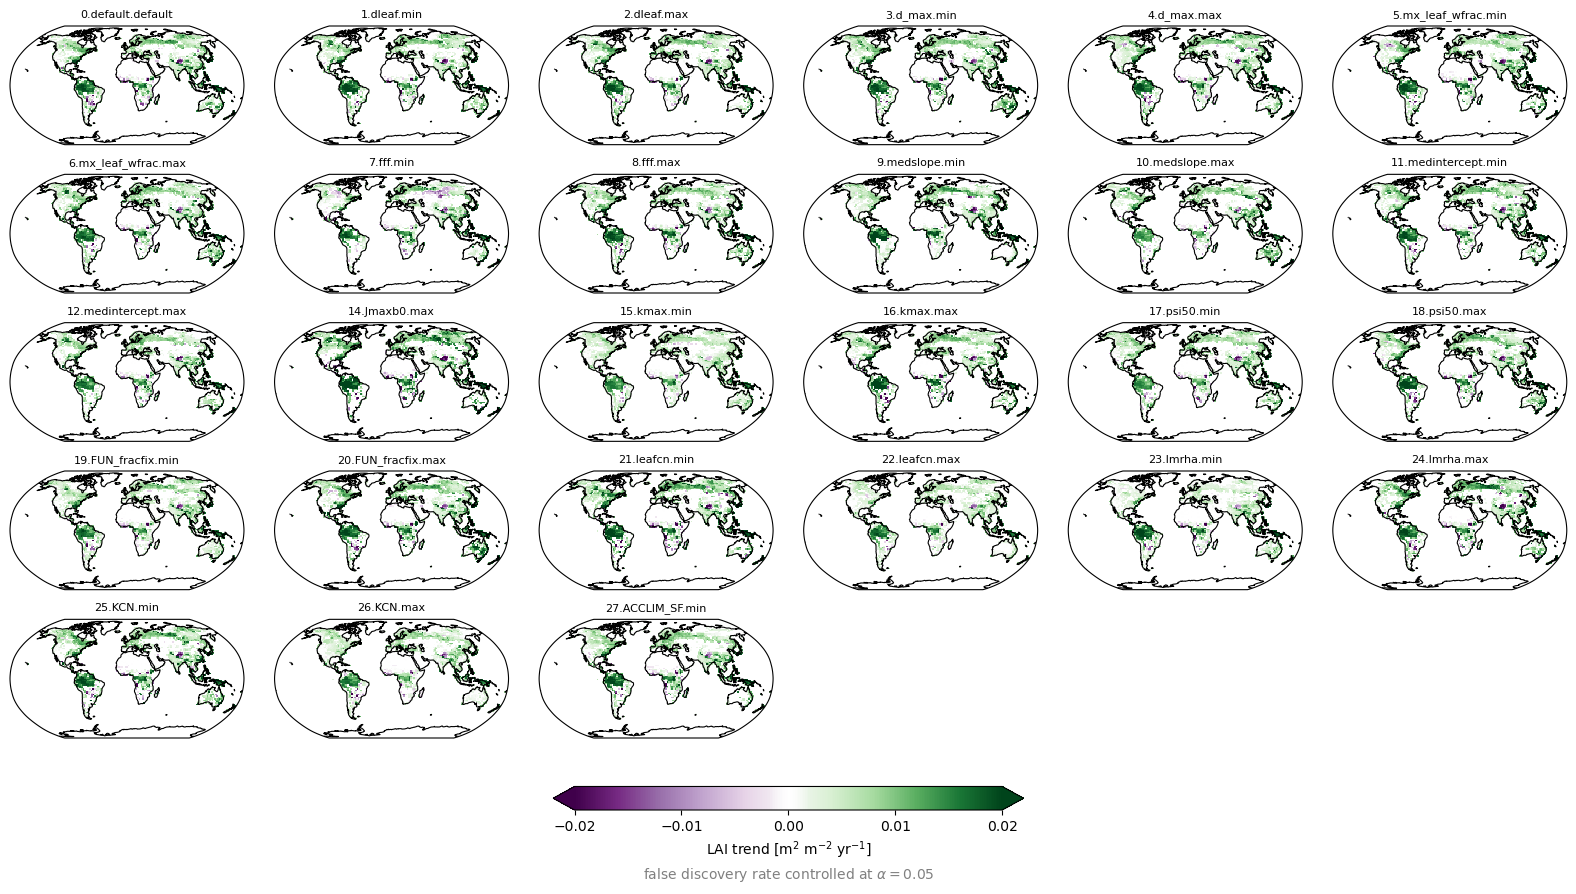

In [81]:
plt.rcdefaults()
fg = xclim.plot.facetgrid_map.plot_facetgrid_map(
    da=lai_yr_ols.slope_fdr_masked,
    dim='member',
    label='LAI trend [m$^{2}$ m$^{-2}$ yr$^{-1}$]',
    parse_name=xclim.ppe.get_member_name,
    cmap=cmap,
    show_outer_labels=True,
    robust=True,
    vmin=-0.02,
    vmax=0.02,
)
fg.cbar.set_ticks([-0.02, -0.01, 0, 0.01, 0.02])



fg.fig.canvas.draw()
cbar_pos = fg.cbar.ax.get_position()

fg.fig.text(
    (cbar_pos.x0 + cbar_pos.x1) / 2,
    cbar_pos.y0 - 0.07,
    f"false discovery rate controlled at $\\alpha = 0.05$",
    ha="center",
    va="top",
    fontsize=10,
    transform=fg.fig.transFigure,
    color='gray',
)

fg.fig.savefig('fig/lmwg/trend.yr.map.lnd.LAI.FHIST.png', dpi=300, bbox_inches='tight')

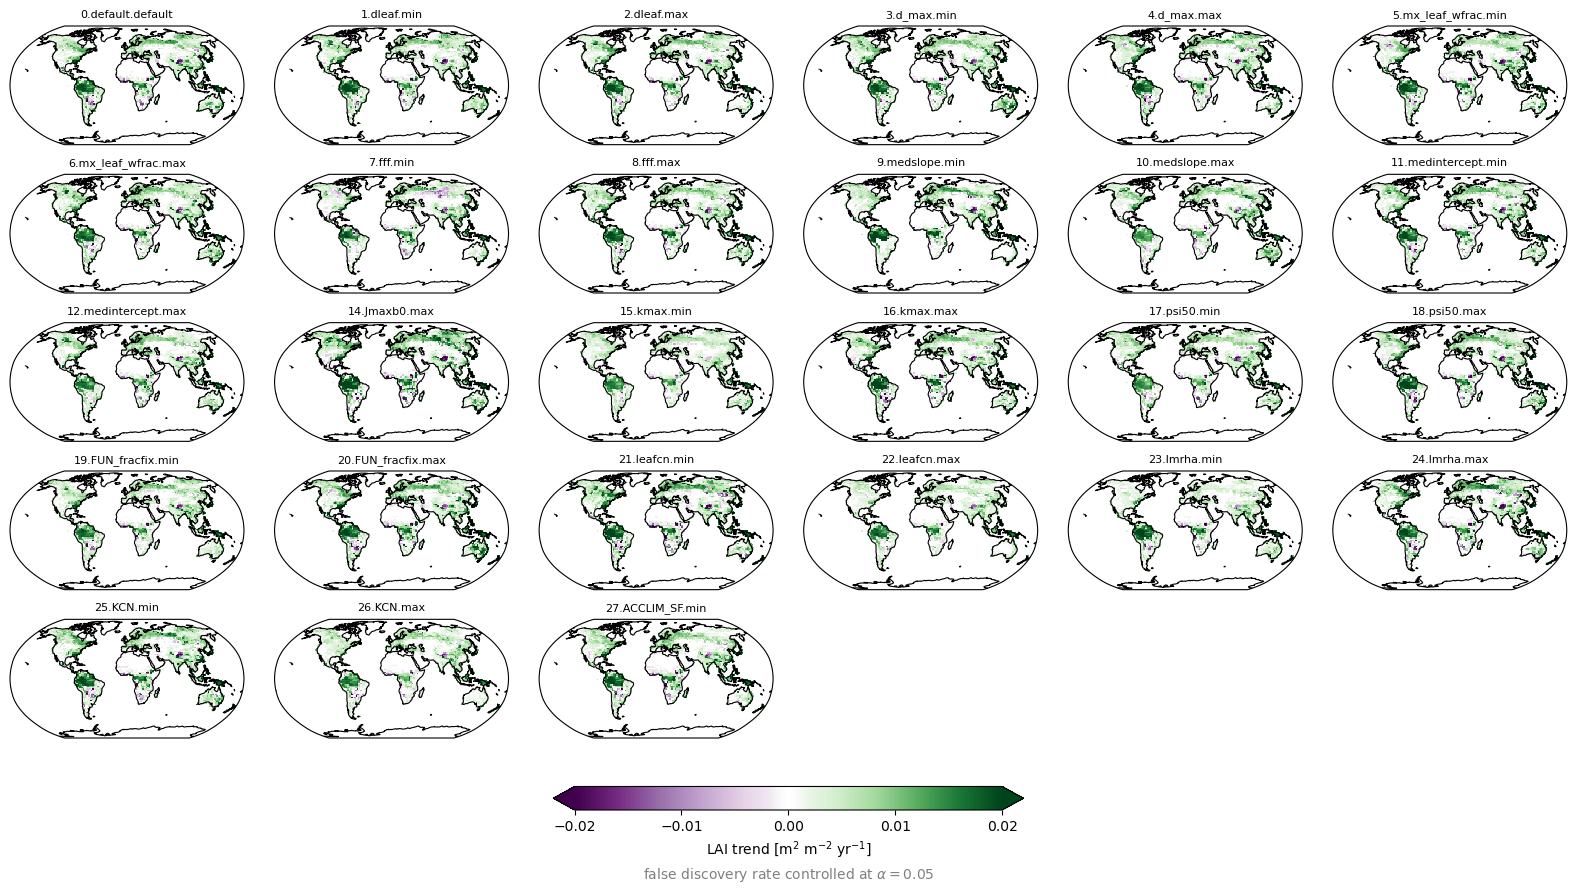

In [86]:
plt.rcdefaults()
fg = xclim.plot.facetgrid_map.plot_facetgrid_map(
    da=lai_dsc_ols.slope_fdr_masked,
    dim='member',
    label='LAI trend [m$^{2}$ m$^{-2}$ yr$^{-1}$]',
    parse_name=xclim.ppe.get_member_name,
    cmap=cmap,
    show_outer_labels=True,
    robust=True,
    vmin=-0.02,
    vmax=0.02,
)
fg.cbar.set_ticks([-0.02, -0.01, 0, 0.01, 0.02])



fg.fig.canvas.draw()
cbar_pos = fg.cbar.ax.get_position()

fg.fig.text(
    (cbar_pos.x0 + cbar_pos.x1) / 2,
    cbar_pos.y0 - 0.07,
    f"false discovery rate controlled at $\\alpha = 0.05$",
    ha="center",
    va="top",
    fontsize=10,
    transform=fg.fig.transFigure,
    color='gray',
)

fg.fig.savefig('fig/lmwg/trend.dsc.map.lnd.LAI.FHIST.png', dpi=300, bbox_inches='tight')

Text(0.49999999999999994, -0.06, 'false discovery rate controlled at $\\alpha = 0.05$')

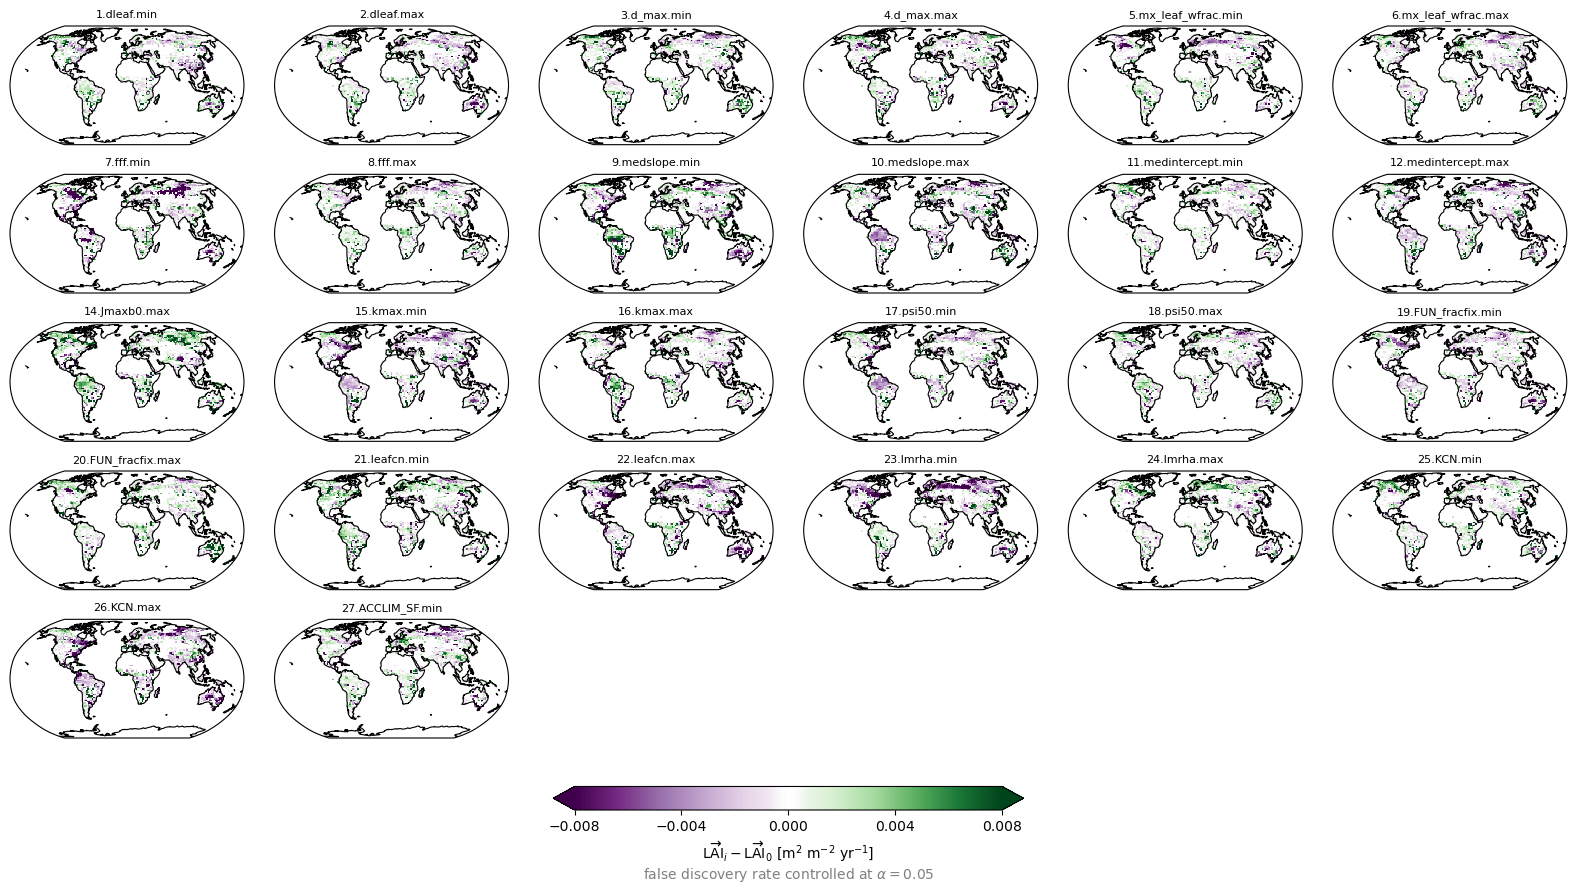

In [92]:
plt.rcdefaults()
fg = xclim.plot.facetgrid_map.plot_facetgrid_map(
    da=(lai_dsc_ols.slope_fdr_masked.sel(member=slice(1, None)) - lai_dsc_ols.slope_fdr_masked.sel(member=0)),
    dim='member',
    label='$\\overrightarrow{\\text{LAI}}_i - \\overrightarrow{\\text{LAI}}_0$ [m$^{2}$ m$^{-2}$ yr$^{-1}$]',
    parse_name=xclim.ppe.get_member_name,
    cmap=cmap,
    show_outer_labels=True,
    robust=True,
    vmin=-0.008,
    vmax=0.008,
)
fg.cbar.set_ticks([-0.008, -0.004, 0, 0.004, 0.008])



fg.fig.canvas.draw()
cbar_pos = fg.cbar.ax.get_position()

fg.fig.text(
    (cbar_pos.x0 + cbar_pos.x1) / 2,
    cbar_pos.y0 - 0.07,
    f"false discovery rate controlled at $\\alpha = 0.05$",
    ha="center",
    va="top",
    fontsize=10,
    transform=fg.fig.transFigure,
    color='gray',
)